LangGraph Single-turn Chatbot

In [1]:
%pip install langgraph -Uqqq

Note: you may need to restart the kernel to use updated packages.


In [2]:

from dotenv import load_dotenv
import os

load_dotenv()
os.environ['OPENAI_API_KEY'] = os.getenv('OPENAI_API_KEY')
os.environ['LANGSMITH_TRACING'] = 'true'
os.environ['LANGSMITH_ENDPOINT'] = 'https://apac.api.smith.langchain.com'
os.environ['LANGSMITH_PROJECT'] = 'skn34-langchain'
os.environ['LANGSMITH_API_KEY'] = os.getenv('LANGSMITH_API_KEY')

State
agent간에 공유될 정보를 State 개체(dict)로써 관리

In [3]:
from typing import TypedDict, Annotated, List     # 타입 힌트 도구
from langgraph.graph.message import add_messages  # 메시지 누적 처리를 해줄 헬퍼

# 그래프에서 사용할 상태(TypedDict) 스키마
class State(TypedDict):
    messages: Annotated[List, add_messages]  # messages 필드가 add_messages 규칙으로 누적 저장

챗봇 노드
Node(Agent) function
Edge

In [4]:

from langchain.chat_models import init_chat_model

llm = init_chat_model('gpt-5.6-luna')

# State의 messages를 입력으로 받아, 응답 메시지를 추가해주는 노드 함수
def chatbot(state: State):
    response = llm.invoke(state['messages'])  # 누적된 메시지 리스트로 LLM 호출
    return {'messages': [response]}  # add_messages 규칙에 의해 기존 messages에 응답이 누적됨


그래프 설계 / 컴파일

<class 'langgraph.graph.state.CompiledStateGraph'>


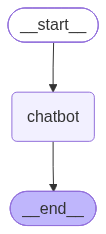

In [5]:

# START -> chatbot -> END로 동작하는 LangGraph 설계
from langgraph.graph import StateGraph, START, END

workflow = StateGraph(State)  # State 스키마 기반 그래프 설계 객체 생성

workflow.add_edge(START, 'chatbot')  # 시작 노드 -> chatbot 노드
workflow.add_node('chatbot', chatbot)  # chatbot 노드
workflow.add_edge('chatbot', END)    # chatbot -> 종료 노드

graph = workflow.compile()  # 설계된 워크프로우를 실행 가능한 그래프로 컴파일
print(type(graph))  # 그래프 타입 확인

graph  # 그래프 객체

In [6]:
user_query = '랭그래프가 뭐죠?'

# messages는 add_messages 규칙에 따라 계속해서 누적됨
state = {
    'messages': [
        ('system', '당신은 현명한 IT전문가 입니다.'),
        ('human', user_query)
    ]
}

response = graph.invoke(state)  # 그래프 실행(START -> chatbot -> END)
print(response)  # 최종 누적 완료된 상태

Failed to multipart ingest runs: langsmith.utils.LangSmithError: Failed to POST https://apac.api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://apac.api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')
Failed to multipart ingest runs: langsmith.utils.LangSmithError: Failed to POST https://apac.api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://apac.api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')
Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://apac.api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://apac.api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


{'messages': [SystemMessage(content='당신은 현명한 IT전문가 입니다.', additional_kwargs={}, response_metadata={}, id='ed8d32ca-b233-463b-bdd4-9ddc0e5917ab'), HumanMessage(content='랭그래프가 뭐죠?', additional_kwargs={}, response_metadata={}, id='6558077a-c56e-4a94-af4c-3a47bb98c57a'), AIMessage(content='랭그래프(LangGraph)는 **LLM 기반 에이전트와 복잡한 AI 워크플로를 그래프 구조로 설계·실행하는 오픈소스 프레임워크**입니다. LangChain 생태계에서 만들어졌으며, 현재는 독립적으로도 사용할 수 있습니다.\n\n### 핵심 개념\n\n- **노드(Node)**: 수행할 작업  \n  예: 질문 분류, 검색, 답변 생성, 검증\n- **엣지(Edge)**: 작업 간 이동 경로\n- **상태(State)**: 각 단계에서 공유되는 데이터\n- **조건 분기**: 결과에 따라 다른 노드로 이동\n- **반복(Loop)**: 답변이 충분할 때까지 재검토\n- **체크포인트**: 실행 상태 저장 및 이어서 실행\n- **사람 개입(Human-in-the-loop)**: 중요한 단계에서 사용자 승인 요청\n\n일반적인 LangChain 체인이 순차적으로 실행되는 데 비해, LangGraph는 다음처럼 **분기·반복·중단·재개가 필요한 에이전트**를 만들기에 적합합니다.\n\n```text\n사용자 질문\n   ↓\n질문 분류\n   ├─ 일반 질문 → 바로 답변\n   ├─ 최신 정보 필요 → 웹 검색 → 답변\n   └─ 문서 검색 필요 → RAG 검색 → 답변\n                         ↓\n                    답변 검증\n                         ↓\n                  부족하

In [7]:
print(response['messages'][-1].content)  # 누적된 messages 중 마지막(모델 응답) 내용 출력

랭그래프(LangGraph)는 **LLM 기반 에이전트와 복잡한 AI 워크플로를 그래프 구조로 설계·실행하는 오픈소스 프레임워크**입니다. LangChain 생태계에서 만들어졌으며, 현재는 독립적으로도 사용할 수 있습니다.

### 핵심 개념

- **노드(Node)**: 수행할 작업  
  예: 질문 분류, 검색, 답변 생성, 검증
- **엣지(Edge)**: 작업 간 이동 경로
- **상태(State)**: 각 단계에서 공유되는 데이터
- **조건 분기**: 결과에 따라 다른 노드로 이동
- **반복(Loop)**: 답변이 충분할 때까지 재검토
- **체크포인트**: 실행 상태 저장 및 이어서 실행
- **사람 개입(Human-in-the-loop)**: 중요한 단계에서 사용자 승인 요청

일반적인 LangChain 체인이 순차적으로 실행되는 데 비해, LangGraph는 다음처럼 **분기·반복·중단·재개가 필요한 에이전트**를 만들기에 적합합니다.

```text
사용자 질문
   ↓
질문 분류
   ├─ 일반 질문 → 바로 답변
   ├─ 최신 정보 필요 → 웹 검색 → 답변
   └─ 문서 검색 필요 → RAG 검색 → 답변
                         ↓
                    답변 검증
                         ↓
                  부족하면 다시 검색
```

### 간단한 예시

고객 상담 AI를 만든다고 하면:

1. 고객 질문을 받음
2. 문의 유형을 분류함
3. 주문 조회가 필요하면 데이터베이스 검색
4. 환불 요청이면 담당자 승인 요청
5. 답변 생성
6. 답변이 부정확하면 다시 검토
7. 대화 상태를 저장

이런 복잡한 흐름을 LangGraph로 관리할 수 있습니다.

### LangChain과의 차이

- **LangChain**: LLM, 프롬프트, 도구, 검색기 등을 연결하는 구성 요소와 체인 제공
- **LangGraph**: 이러한 구성 요소를 사용해 **상태를 가진

Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://apac.api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://apac.api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')
